In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

# 设置随机种子，保证结果可复现
np.random.seed(42)

# 中文显示设置
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 基础工具函数

In [9]:
def sigmoid(x):
    """Logistic 函数，用于生成处理概率。"""
    return 1 / (1 + np.exp(-x))


def estimate_propensity_score(data, covariates):
    """
    使用 Logistic 回归估计倾向得分 P(D=1|X)。
    
    参数：
    data: DataFrame，包含处理变量 D 和协变量
    covariates: list，用于估计倾向得分的协变量名称
    
    返回：
    data: 增加 pscore 列后的 DataFrame
    """
    model = LogisticRegression(max_iter=1000)
    X = data[covariates]
    y = data["D"]
    model.fit(X, y)
    
    data = data.copy()
    data["pscore"] = model.predict_proba(X)[:, 1]
    return data


def apply_common_support(data):

    """

    使用 min-max 规则处理共同支持域。

    只保留处理组和对照组倾向得分分布重叠区间内的样本。

    即：

    lower = max(min(pscore_treated), min(pscore_control))

    upper = min(max(pscore_treated), max(pscore_control))

    参数：

    data: 已经包含 pscore 的 DataFrame

    返回：

    data_cs: 保留共同支持域后的 DataFrame

    """

    data = data.copy()

    treated = data[data["D"] == 1]

    control = data[data["D"] == 0]

    if len(treated) == 0 or len(control) == 0:

        return pd.DataFrame()

    treated_min, treated_max = treated["pscore"].min(), treated["pscore"].max()

    control_min, control_max = control["pscore"].min(), control["pscore"].max()

    lower = max(treated_min, control_min)

    upper = min(treated_max, control_max)

    data_cs = data[(data["pscore"] >= lower) & (data["pscore"] <= upper)].copy()

    return data_cs


def nearest_neighbor_match(data, caliper="auto"):

    """

    基于倾向得分进行 1:1 最近邻匹配。

    匹配设定：

    1. 使用 min-max 规则处理共同支持域；

    2. 对每个处理组个体，在对照组中寻找倾向得分最近的 1 个个体；

    3. 采用有放回匹配，即同一个对照组个体可以被多个处理组个体匹配；

    4. 若 caliper="auto"，则设定 caliper = 0.2 × SD(pscore)；

    5. 若最近邻距离超过 caliper，则该处理组个体被剔除；

    6. 返回匹配后的处理组与对照组样本，并记录 match_id 和 match_distance。

    参数：

    data: 已经包含 pscore 的 DataFrame

    caliper: "auto"、None 或具体数值

    返回：

    matched_data: 匹配后的 DataFrame

    """

    data = data.copy()

    # 1. 共同支持域处理

    data = apply_common_support(data)

    if data.empty:

        return pd.DataFrame()

    treated = data[data["D"] == 1].copy()

    control = data[data["D"] == 0].copy()

    if len(treated) == 0 or len(control) == 0:

        return pd.DataFrame()

    # 2. 设置卡尺

    if caliper == "auto":

        caliper_value = 0.2 * data["pscore"].std()

    elif caliper is None:

        caliper_value = None

    else:

        caliper_value = caliper

    # 3. 最近邻匹配，n_neighbors=1

    nn = NearestNeighbors(n_neighbors=1)

    nn.fit(control[["pscore"]])

    distances, indices = nn.kneighbors(treated[["pscore"]])

    matched_treated = []

    matched_control = []

    for i, dist in enumerate(distances.flatten()):

        # 如果设置了卡尺，且距离超过卡尺，则剔除该处理组个体

        if caliper_value is not None and dist > caliper_value:

            continue

        treated_i = treated.iloc[[i]].copy()

        control_i = control.iloc[[indices.flatten()[i]]].copy()

        # 记录匹配编号和匹配距离，方便后续检查匹配质量

        treated_i["match_id"] = i

        control_i["match_id"] = i

        treated_i["match_distance"] = dist

        control_i["match_distance"] = dist

        matched_treated.append(treated_i)

        matched_control.append(control_i)

    if len(matched_treated) == 0:

        return pd.DataFrame()

    matched_data = pd.concat(matched_treated + matched_control, axis=0)

    return matched_data


def estimate_psm_post(data):
    """
    单独 PSM：匹配后比较处理后结果 Y1 的均值差。
    """
    data = estimate_propensity_score(data, ["X"])
    matched = nearest_neighbor_match(data)
    
    if matched.empty:
        return np.nan
    
    treated_mean = matched[matched["D"] == 1]["Y1"].mean()
    control_mean = matched[matched["D"] == 0]["Y1"].mean()
    return treated_mean - control_mean


def estimate_did(data):
    """
    单独 DID：比较处理组和对照组的结果变化差异。
    等价于 DeltaY 对 D 的简单回归。
    """
    data = data.copy()
    data["DeltaY"] = data["Y1"] - data["Y0"]
    
    X_reg = sm.add_constant(data["D"])
    model = sm.OLS(data["DeltaY"], X_reg).fit()
    return model.params["D"]


def estimate_did_with_x(data):
    """
    控制 X 的 DID：DeltaY 对 D 和 X 回归。
    如果 X 影响结果变化趋势，这个模型可以修正部分偏误。
    """
    data = data.copy()
    data["DeltaY"] = data["Y1"] - data["Y0"]
    
    X_reg = sm.add_constant(data[["D", "X"]])
    model = sm.OLS(data["DeltaY"], X_reg).fit()
    return model.params["D"]


def estimate_psm_did(data):
    """
    PSM-DID：先根据 X 估计倾向得分并匹配，再在匹配样本上比较 DeltaY。
    """
    data = data.copy()
    data["DeltaY"] = data["Y1"] - data["Y0"]
    
    data = estimate_propensity_score(data, ["X"])
    matched = nearest_neighbor_match(data)
    
    if matched.empty:
        return np.nan
    
    treated_mean = matched[matched["D"] == 1]["DeltaY"].mean()
    control_mean = matched[matched["D"] == 0]["DeltaY"].mean()
    return treated_mean - control_mean


def summarize_results(results_df, true_effect=2.0):
    """
    汇总 Monte Carlo 结果：Mean Estimate, Bias, RMSE, Std。
    """
    summary = []
    
    for scenario in results_df["scenario"].unique():
        temp_s = results_df[results_df["scenario"] == scenario]
        
        for method in ["PSM", "DID", "DID_X", "PSM_DID"]:
            estimates = temp_s[method].dropna()
            
            mean_est = estimates.mean()
            bias = mean_est - true_effect
            rmse = np.sqrt(np.mean((estimates - true_effect) ** 2))
            std = estimates.std()
            
            summary.append({
                "Scenario": scenario,
                "Method": method,
                "Mean_Estimate": mean_est,
                "Bias": bias,
                "RMSE": rmse,
                "Std": std
            })
    
    return pd.DataFrame(summary)

# 场景A


In [10]:
def generate_data_scenario_A(n=1000, tau=2.0):
    """
    场景 A：无条件平行趋势成立。
    
    X 影响处理选择和结果水平，但不影响结果变化趋势。
    因此，未处理状态下，处理组和对照组具有相同的自然变化趋势。
    """
    X = np.random.normal(0, 1, n)
    alpha = np.random.normal(0, 1, n)
    
    # 处理分配：X 越高，越可能接受处理
    p = sigmoid(-0.2 + 0.8 * X)
    D = np.random.binomial(1, p, n)
    
    # 处理前结果
    eps0 = np.random.normal(0, 1, n)
    Y0 = alpha + 1.5 * X + eps0
    
    # 共同时间趋势
    lambda_t = 1.0
    
    # 处理后结果：X 不影响趋势，只影响水平
    eps1 = np.random.normal(0, 1, n)
    Y1 = alpha + 1.5 * X + lambda_t + tau * D + eps1
    
    data = pd.DataFrame({
        "X": X,
        "D": D,
        "Y0": Y0,
        "Y1": Y1
    })
    
    return data

# 场景B

In [11]:
def generate_data_scenario_B(n=1000, tau=2.0):
    """
    场景 B：趋势差异由可观测协变量 X 决定。
    
    X 同时影响处理选择和结果变化趋势。
    未匹配时，无条件平行趋势不成立；
    但在给定 X 或匹配 X 后，条件平行趋势成立。
    """
    X = np.random.normal(0, 1, n)
    alpha = np.random.normal(0, 1, n)
    
    # 处理分配：X 越高，越可能接受处理
    p = sigmoid(-0.2 + 0.8 * X)
    D = np.random.binomial(1, p, n)
    
    # 处理前结果
    eps0 = np.random.normal(0, 1, n)
    Y0 = alpha + 1.5 * X + eps0
    
    # 共同时间趋势
    lambda_t = 1.0
    
    # X 对自然增长趋势的影响
    delta_x = 1.0
    
    # 处理后结果：X 影响结果变化趋势
    eps1 = np.random.normal(0, 1, n)
    Y1 = alpha + 1.5 * X + lambda_t + delta_x * X + tau * D + eps1
    
    data = pd.DataFrame({
        "X": X,
        "D": D,
        "Y0": Y0,
        "Y1": Y1
    })
    
    return data

# 场景C

In [12]:
def generate_data_scenario_C(n=1000, tau=2.0):
    """
    场景 C：存在不可观测时间变化混淆。
    
    U 同时影响处理选择和结果变化趋势，但研究者无法观察 U。
    即使匹配 X，也无法消除 U 带来的趋势差异。
    因此 PSM-DID 也会有偏。
    """
    X = np.random.normal(0, 1, n)
    U = np.random.normal(0, 1, n)  # 不可观测变量
    alpha = np.random.normal(0, 1, n)
    
    # 处理分配由 X 和 U 共同决定
    p = sigmoid(-0.2 + 0.6 * X + 0.9 * U)
    D = np.random.binomial(1, p, n)
    
    # 处理前结果
    eps0 = np.random.normal(0, 1, n)
    Y0 = alpha + 1.5 * X + 1.0 * U + eps0
    
    # 共同时间趋势
    lambda_t = 1.0
    
    # X 和 U 都影响自然增长趋势
    delta_x = 1.0
    rho_u = 1.2
    
    # 处理后结果
    eps1 = np.random.normal(0, 1, n)
    Y1 = alpha + 1.5 * X + 1.0 * U + lambda_t + delta_x * X + rho_u * U + tau * D + eps1
    
    # 注意：返回的数据不包含 U，因为研究者观察不到它
    data = pd.DataFrame({
        "X": X,
        "D": D,
        "Y0": Y0,
        "Y1": Y1
    })
    
    return data

# 单次模拟函数

In [13]:
def run_one_simulation(data_generator, scenario_name, n=1000, tau=2.0):
    """
    对某一个场景运行一次模拟，并返回四种方法的估计结果。
    """
    data = data_generator(n=n, tau=tau)
    
    try:
        psm_est = estimate_psm_post(data)
    except Exception:
        psm_est = np.nan
    
    try:
        did_est = estimate_did(data)
    except Exception:
        did_est = np.nan
    
    try:
        did_x_est = estimate_did_with_x(data)
    except Exception:
        did_x_est = np.nan
    
    try:
        psm_did_est = estimate_psm_did(data)
    except Exception:
        psm_did_est = np.nan
    
    return {
        "scenario": scenario_name,
        "PSM": psm_est,
        "DID": did_est,
        "DID_X": did_x_est,
        "PSM_DID": psm_did_est
    }

# 蒙特卡洛主循环

In [14]:
def run_monte_carlo(R=500, n=1000, tau=2.0):
    """
    对三个场景分别进行 Monte Carlo 模拟。
    
    R: 每个场景重复次数
    n: 每次模拟的样本量
    tau: 真实处理效应
    """
    all_results = []
    
    scenarios = {
        "A_Unconditional_Parallel_Trend": generate_data_scenario_A,
        "B_Conditional_Parallel_Trend": generate_data_scenario_B,
        "C_Unobserved_Time_Varying_Confounding": generate_data_scenario_C
    }
    
    for scenario_name, generator in scenarios.items():
        print(f"Running scenario: {scenario_name}")
        
        for r in range(R):
            result = run_one_simulation(
                data_generator=generator,
                scenario_name=scenario_name,
                n=n,
                tau=tau
            )
            result["replication"] = r + 1
            all_results.append(result)
    
    results_df = pd.DataFrame(all_results)
    return results_df

In [15]:
true_effect = 2.0

results_df = run_monte_carlo(R=500, n=1000, tau=true_effect)

results_df.head()

Running scenario: A_Unconditional_Parallel_Trend
Running scenario: B_Conditional_Parallel_Trend
Running scenario: C_Unobserved_Time_Varying_Confounding


,scenario,PSM,DID,DID_X,PSM_DID,replication
0,A_Unconditional_Parallel_Trend,2.078647,1.980425,2.007092,2.027642,1
1,A_Unconditional_Parallel_Trend,1.887434,1.853195,1.936382,1.849832,2
2,A_Unconditional_Parallel_Trend,2.046513,1.980185,1.970861,1.876856,3
3,A_Unconditional_Parallel_Trend,1.927534,1.877080,1.897296,1.861364,4
4,A_Unconditional_Parallel_Trend,2.122210,1.986367,1.951115,2.034364,5


# 结果汇总

In [16]:
summary_df = summarize_results(results_df, true_effect=true_effect)

summary_df

,Scenario,Method,Mean_Estimate,Bias,RMSE,Std
0,A_Unconditional_Parallel_Trend,PSM,2.009984,0.009984,0.127433,0.127168
1,A_Unconditional_Parallel_Trend,DID,1.999410,-0.000590,0.088049,0.088136
2,A_Unconditional_Parallel_Trend,DID_X,1.999270,-0.000730,0.093881,0.093972
3,A_Unconditional_Parallel_Trend,PSM_DID,1.992524,-0.007476,0.133940,0.133865
4,B_Conditional_Parallel_Trend,PSM,1.992923,-0.007077,0.134928,0.134878
5,B_Conditional_Parallel_Trend,DID,2.697292,0.697292,0.706236,0.112153
6,B_Conditional_Parallel_Trend,DID_X,2.000804,0.000804,0.095379,0.095471
7,B_Conditional_Parallel_Trend,PSM_DID,1.996984,-0.003016,0.130355,0.130451
8,C_Unobserved_Time_Varying_Confounding,PSM,3.691385,1.691385,1.704297,0.209598
9,C_Unobserved_Time_Varying_Confounding,DID,3.357431,1.357431,1.362972,0.122894


In [17]:
os.makedirs("../outputs", exist_ok=True)

results_df.to_csv("../outputs/simulation_raw_results.csv", index=False)
summary_df.to_csv("../outputs/simulation_summary.csv", index=False)

# 估计值分布图

In [18]:
os.makedirs("../figures", exist_ok=True)

def plot_distribution_by_scenario(results_df, scenario_name, true_effect=2.0):
    """
    绘制某一场景下四种方法的估计值分布。
    """
    temp = results_df[results_df["scenario"] == scenario_name]
    
    methods = ["PSM", "DID", "DID_X", "PSM_DID"]
    
    plt.figure(figsize=(10, 6))
    
    for method in methods:
        estimates = temp[method].dropna()
        plt.hist(estimates, bins=30, alpha=0.4, density=True, label=method)
    
    plt.axvline(true_effect, linestyle="--", linewidth=2, label=f"True Effect = {true_effect}")
    plt.xlabel("Estimated Treatment Effect")
    plt.ylabel("Density")
    plt.title(f"Distribution of Estimates: {scenario_name}")
    plt.legend()
    plt.tight_layout()
    
    file_name = f"../figures/{scenario_name}_distribution.png"
    plt.savefig(file_name, dpi=300)
    plt.show()
    
    print(f"Saved to {file_name}")

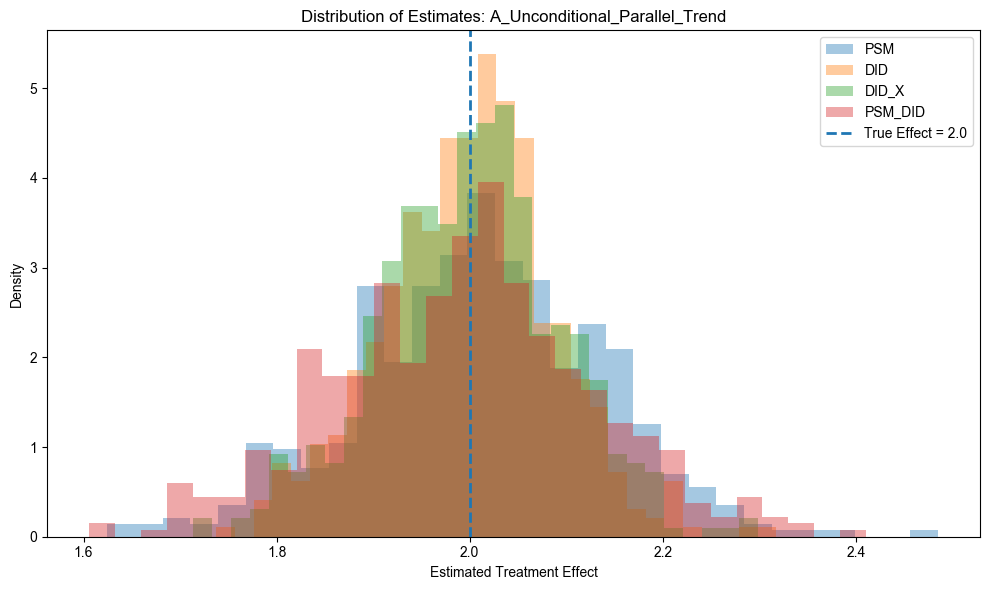

Saved to ../figures/A_Unconditional_Parallel_Trend_distribution.png


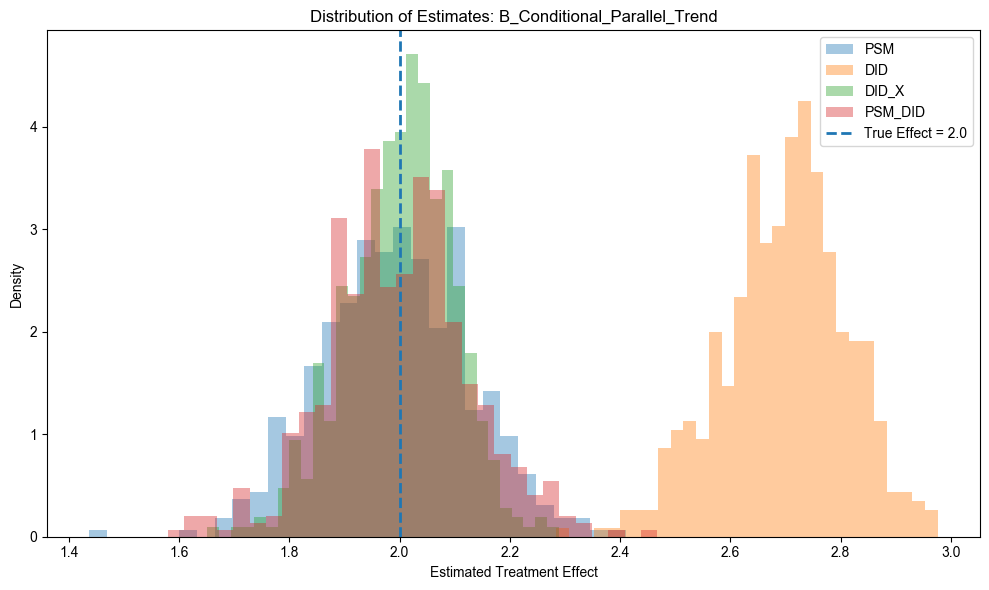

Saved to ../figures/B_Conditional_Parallel_Trend_distribution.png


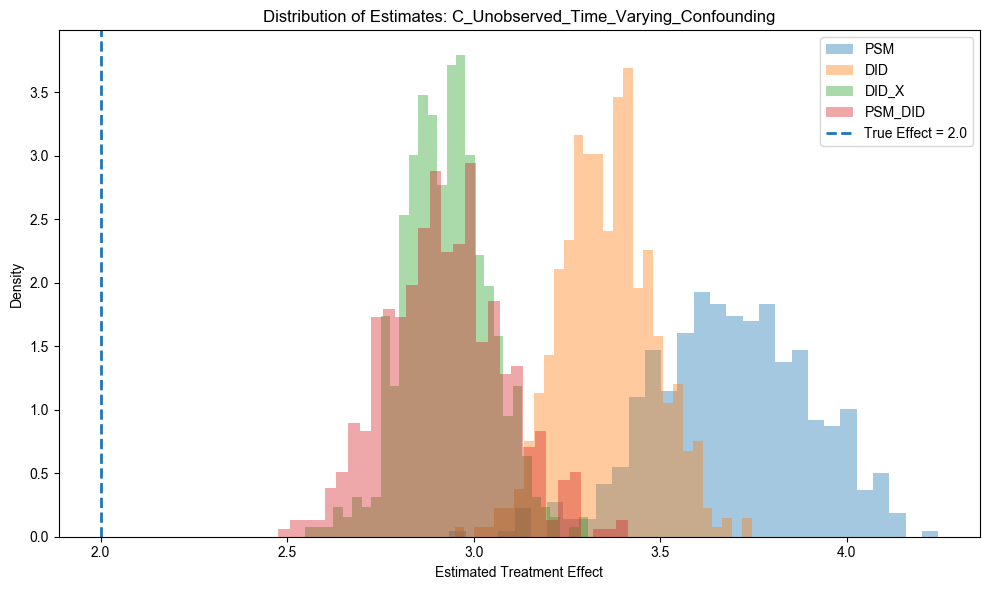

Saved to ../figures/C_Unobserved_Time_Varying_Confounding_distribution.png


In [19]:
for scenario in results_df["scenario"].unique():
    plot_distribution_by_scenario(results_df, scenario, true_effect=true_effect)

# Bias & RMSE对比图

In [20]:
def plot_bias_rmse(summary_df):
    """
    绘制不同场景和方法的 Bias 与 RMSE 对比图。
    """
    os.makedirs("../figures", exist_ok=True)
    
    for metric in ["Bias", "RMSE"]:
        plt.figure(figsize=(12, 6))
        
        pivot_df = summary_df.pivot(index="Scenario", columns="Method", values=metric)
        pivot_df.plot(kind="bar", figsize=(12, 6))
        
        plt.axhline(0, linewidth=1)
        plt.ylabel(metric)
        plt.title(f"{metric} Comparison Across Scenarios")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        
        file_name = f"../figures/{metric.lower()}_comparison.png"
        plt.savefig(file_name, dpi=300)
        plt.show()
        
        print(f"Saved to {file_name}")

<Figure size 1200x600 with 0 Axes>

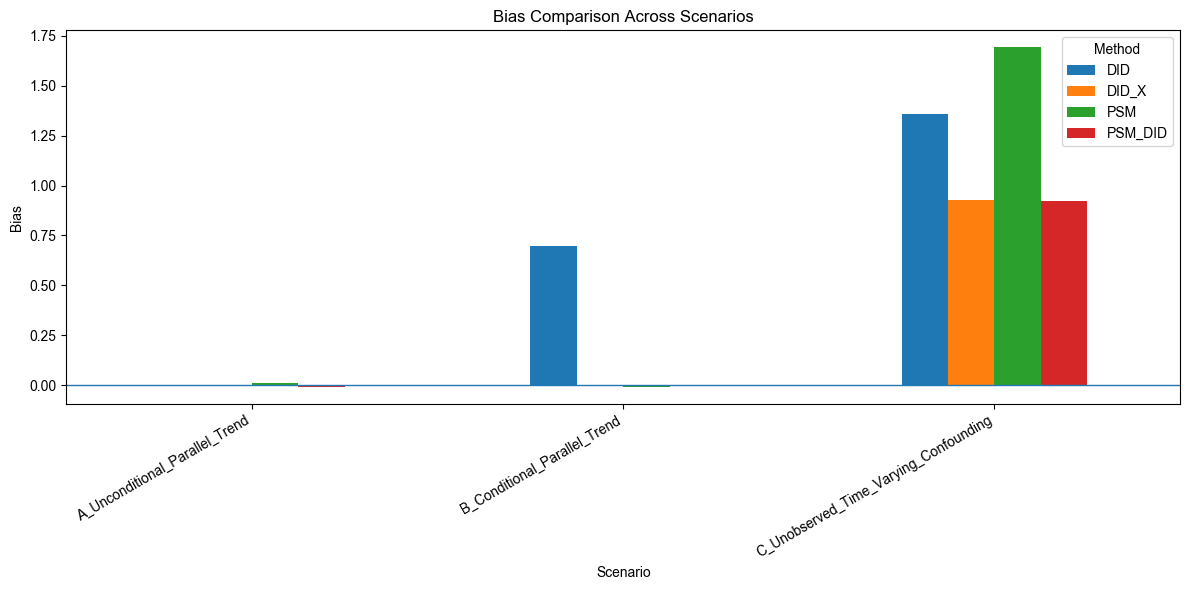

Saved to ../figures/bias_comparison.png


<Figure size 1200x600 with 0 Axes>

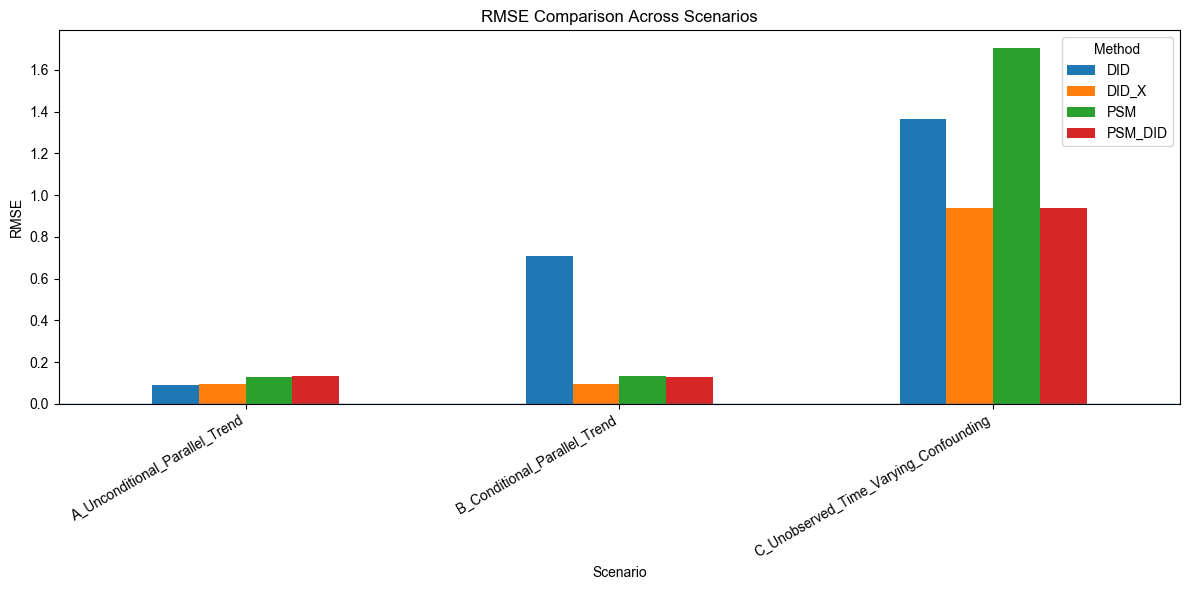

Saved to ../figures/rmse_comparison.png


In [21]:
plot_bias_rmse(summary_df)

# 平衡性检验

In [22]:
def standardized_mean_difference(data, var):
    """
    计算某个变量在处理组和对照组之间的标准化均值差异 SMD。
    """
    treated = data[data["D"] == 1][var]
    control = data[data["D"] == 0][var]
    
    mean_diff = treated.mean() - control.mean()
    pooled_sd = np.sqrt((treated.var() + control.var()) / 2)
    
    return mean_diff / pooled_sd


def balance_check_one_dataset(data_generator, scenario_name, n=1000, tau=2.0):
    """
    对某一个场景生成一份数据，展示匹配前后 X 的平衡性。
    """
    data = data_generator(n=n, tau=tau)
    data = estimate_propensity_score(data, ["X"])

    matched = nearest_neighbor_match(data)

    smd_before = standardized_mean_difference(data, "X")

    if matched.empty:
        smd_after = np.nan
        matched_n = 0
    else:
        smd_after = standardized_mean_difference(matched, "X")
        matched_n = len(matched)

    balance_df = pd.DataFrame({
        "Scenario": [scenario_name, scenario_name],
        "Stage": ["Before Matching", "After Matching"],
        "SMD_X": [smd_before, smd_after],
        "N": [len(data), matched_n]
    })

    return balance_df, data, matched

In [23]:
balance_results = []

for scenario_name, generator in {
    "A_Unconditional_Parallel_Trend": generate_data_scenario_A,
    "B_Conditional_Parallel_Trend": generate_data_scenario_B,
    "C_Unobserved_Time_Varying_Confounding": generate_data_scenario_C
}.items():
    balance_df, _, _ = balance_check_one_dataset(generator, scenario_name)
    balance_results.append(balance_df)

balance_summary = pd.concat(balance_results, axis=0)
balance_summary

,Scenario,Stage,SMD_X,N
0,A_Unconditional_Parallel_Trend,Before Matching,0.793502,1000
1,A_Unconditional_Parallel_Trend,After Matching,0.001491,986
0,B_Conditional_Parallel_Trend,Before Matching,0.826517,1000
1,B_Conditional_Parallel_Trend,After Matching,-0.000604,862
0,C_Unobserved_Time_Varying_Confounding,Before Matching,0.615715,1000
1,C_Unobserved_Time_Varying_Confounding,After Matching,-0.000354,928


In [24]:
balance_summary.to_csv("../outputs/balance_summary.csv", index=False)

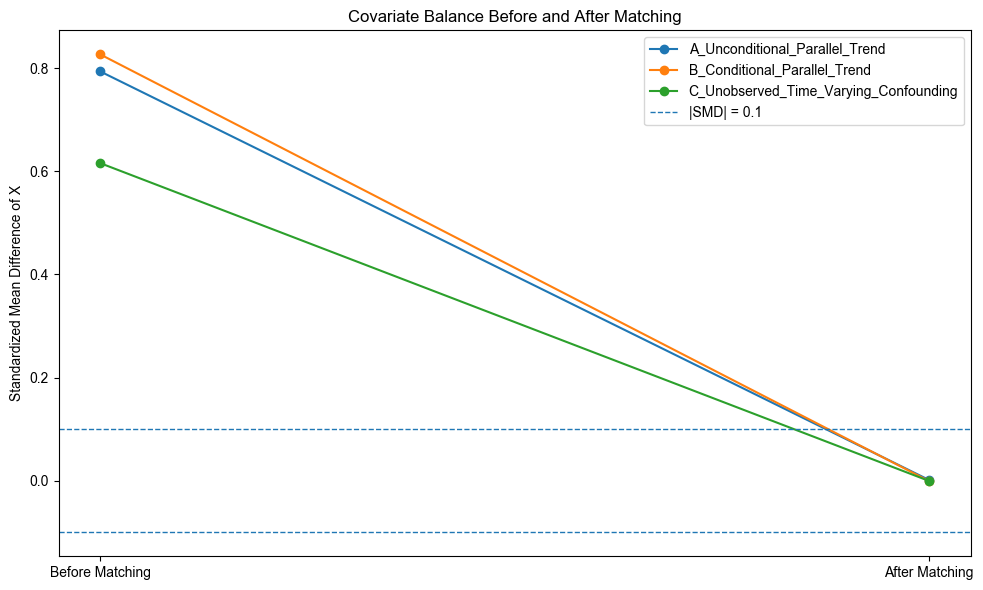

In [25]:
plt.figure(figsize=(10, 6))

for scenario in balance_summary["Scenario"].unique():
    temp = balance_summary[balance_summary["Scenario"] == scenario]
    plt.plot(temp["Stage"], temp["SMD_X"], marker="o", label=scenario)

plt.axhline(0.1, linestyle="--", linewidth=1, label="|SMD| = 0.1")
plt.axhline(-0.1, linestyle="--", linewidth=1)
plt.ylabel("Standardized Mean Difference of X")
plt.title("Covariate Balance Before and After Matching")
plt.legend()
plt.tight_layout()

plt.savefig("../figures/balance_before_after.png", dpi=300)
plt.show()

In [26]:
def matching_diagnostics_one_dataset(data_generator, scenario_name, n=1000, tau=2.0):
    """
    样本损失检验
    检查某一场景下匹配前后样本数量、处理组数量和平均匹配距离。
    """
    data = data_generator(n=n, tau=tau)
    data = estimate_propensity_score(data, ["X"])

    matched = nearest_neighbor_match(data)

    if matched.empty:
        diagnostics = {
            "Scenario": scenario_name,
            "Original_N": len(data),
            "Original_Treated_N": (data["D"] == 1).sum(),
            "Original_Control_N": (data["D"] == 0).sum(),
            "Matched_N": 0,
            "Matched_Treated_N": 0,
            "Matched_Control_N": 0,
            "Mean_Match_Distance": np.nan
        }
    else:
        diagnostics = {
            "Scenario": scenario_name,
            "Original_N": len(data),
            "Original_Treated_N": (data["D"] == 1).sum(),
            "Original_Control_N": (data["D"] == 0).sum(),
            "Matched_N": len(matched),
            "Matched_Treated_N": (matched["D"] == 1).sum(),
            "Matched_Control_N": (matched["D"] == 0).sum(),
            "Mean_Match_Distance": matched["match_distance"].mean()
        }

    return diagnostics

In [27]:
diagnostics_list = []

for scenario_name, generator in {
    "A_Unconditional_Parallel_Trend": generate_data_scenario_A,
    "B_Conditional_Parallel_Trend": generate_data_scenario_B,
    "C_Unobserved_Time_Varying_Confounding": generate_data_scenario_C
}.items():
    diagnostics_list.append(
        matching_diagnostics_one_dataset(generator, scenario_name, n=1000, tau=true_effect)
    )

matching_diagnostics_df = pd.DataFrame(diagnostics_list)
matching_diagnostics_df


,Scenario,Original_N,Original_Treated_N,Original_Control_N,Matched_N,Matched_Treated_N,Matched_Control_N,Mean_Match_Distance
0,A_Unconditional_Parallel_Trend,1000,446,554,878,439,439,0.001148
1,B_Conditional_Parallel_Trend,1000,473,527,942,471,471,0.001014
2,C_Unobserved_Time_Varying_Confounding,1000,464,536,924,462,462,0.000643


In [28]:
matching_diagnostics_df.to_csv("../outputs/matching_diagnostics.csv", index=False)

# 倾向得分共同支持图

In [29]:
def plot_common_support(data_generator, scenario_name, n=1000, tau=2.0):
    """
    绘制处理组和对照组的倾向得分分布，检查共同支持域。
    """
    data = data_generator(n=n, tau=tau)
    data = estimate_propensity_score(data, ["X"])
    
    treated_ps = data[data["D"] == 1]["pscore"]
    control_ps = data[data["D"] == 0]["pscore"]
    
    plt.figure(figsize=(10, 6))
    plt.hist(treated_ps, bins=30, alpha=0.5, density=True, label="Treated")
    plt.hist(control_ps, bins=30, alpha=0.5, density=True, label="Control")
    
    plt.xlabel("Estimated Propensity Score")
    plt.ylabel("Density")
    plt.title(f"Common Support Check: {scenario_name}")
    plt.legend()
    plt.tight_layout()
    
    file_name = f"../figures/{scenario_name}_common_support.png"
    plt.savefig(file_name, dpi=300)
    plt.show()
    
    print(f"Saved to {file_name}")

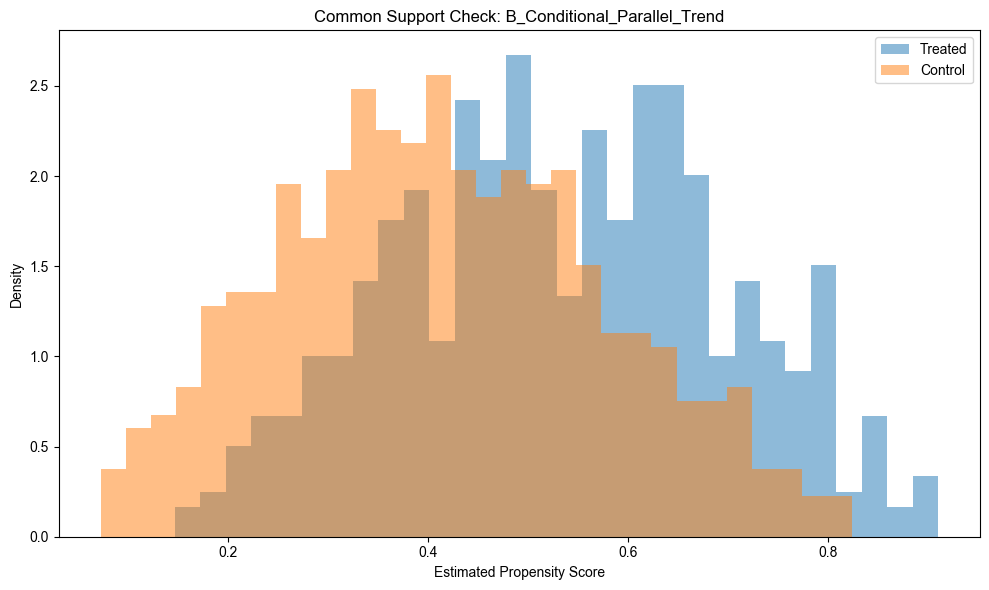

Saved to ../figures/B_Conditional_Parallel_Trend_common_support.png


In [30]:
plot_common_support(
    generate_data_scenario_B,
    "B_Conditional_Parallel_Trend",
    n=1000,
    tau=true_effect
)